# MelCNN MGR Manifest and Log-Mel EDA

This notebook follows the current MelCNN MGR data pipeline as one continuous audit, starting at file discovery, moving through segment generation and final split selection, then branching into two downstream readiness checks: small-split supplementation state and optional log-mel cache materialization.

The audit is centered on:

1. `1_build_all_datasets_and_samples.py`
2. `2_build_log_mel_dataset.py`
3. the manifest parquet files in `MelCNN-MGR/data/processed`
4. the optional downstream log-mel cache outputs in `MelCNN-MGR/cache/logmel_dataset_10s`

The goal is not just to inspect isolated artifacts, but to verify that the current multi-source manifest scheme remains coherent from upstream discovery to training-ready outputs.

## Notebook Map

The notebook follows the pipeline in execution order, then adds targeted downstream checks where they matter:

1. resolve paths and load configuration
2. inspect processed manifest artifacts and schema contract
3. audit file-level discovery and skip logic
4. audit segment expansion and final split selection
5. check leakage safety and additional-source contribution
6. zoom into the small-split workflow with a supplementation-aware audit when those artifacts exist
7. inspect optional downstream log-mel cache outputs
8. summarize readiness, divergence, and remaining gaps

In [2]:
from __future__ import annotations

import hashlib
import json
import random
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', 140)

NOTEBOOK_NAME = 'MelCNN_MGR_Manifest_LogMel_EDA'


def resolve_project_paths(start: Path) -> tuple[Path, Path]:
    candidates = [start.resolve(), *start.resolve().parents]
    for candidate in candidates:
        if (candidate / 'MelCNN-MGR' / 'settings.json').exists():
            return candidate, candidate / 'MelCNN-MGR'
        if candidate.name == 'MelCNN-MGR' and (candidate / 'settings.json').exists():
            return candidate.parent, candidate
    raise FileNotFoundError('Could not locate workspace root containing MelCNN-MGR/settings.json')


WORKSPACE_ROOT, MELCNN_DIR = resolve_project_paths(Path.cwd())
PROCESSED_DIR = MELCNN_DIR / 'data' / 'processed'
CACHE_DIR = MELCNN_DIR / 'cache'
SETTINGS_PATH = MELCNN_DIR / 'settings.json'
MANIFEST_CONFIG_PATH = PROCESSED_DIR / 'manifest_all_datasets.config.json'
MANIFEST_REPORT_PATH = PROCESSED_DIR / 'manifest_all_datasets.report.txt'
ALL_DATASETS_PATH = PROCESSED_DIR / 'manifest_all_datasets.parquet'
ALL_SAMPLES_PATH = PROCESSED_DIR / 'manifest_all_samples.parquet'
FINAL_SAMPLES_PATH = PROCESSED_DIR / 'manifest_final_samples.parquet'
TRACKS_CSV = WORKSPACE_ROOT / 'FMA' / 'fma_metadata' / 'tracks.csv'
EXTRA_SAMPLES_PATH = PROCESSED_DIR / 'extra_samples_for_small_dataset.json'
SUPPLEMENTED_TARGET_SUBSET = 'small'
SUPPLEMENTED_SPLIT_ORDER = ['training', 'validation', 'test']
SUPPLEMENTED_SPLIT_FILES = {
    'training': f'train_{SUPPLEMENTED_TARGET_SUBSET}.parquet',
    'validation': f'val_{SUPPLEMENTED_TARGET_SUBSET}.parquet',
    'test': f'test_{SUPPLEMENTED_TARGET_SUBSET}.parquet',
}
SUPPLEMENTATION_BASE_RANDOM_SEED = 20260309

LOGMEL_DATASET_DIR = Path('MelCNN-MGR/cache/logmel_dataset_10s')
if not LOGMEL_DATASET_DIR.is_absolute():
    LOGMEL_DATASET_DIR = WORKSPACE_ROOT / LOGMEL_DATASET_DIR
LOGMEL_CONFIG_PATH = LOGMEL_DATASET_DIR / 'logmel_config.json'
LOGMEL_ALL_PATH = LOGMEL_DATASET_DIR / 'logmel_manifest_all.parquet'
LOGMEL_TRAIN_PATH = LOGMEL_DATASET_DIR / 'logmel_manifest_train.parquet'
LOGMEL_VAL_PATH = LOGMEL_DATASET_DIR / 'logmel_manifest_val.parquet'
LOGMEL_TEST_PATH = LOGMEL_DATASET_DIR / 'logmel_manifest_test.parquet'

print(f'Loaded helpers for {NOTEBOOK_NAME}')
print(f'Workspace root: {WORKSPACE_ROOT}')
print(f'Processed dir : {PROCESSED_DIR}')
print(f'Log-mel dir   : {LOGMEL_DATASET_DIR}')

Loaded helpers for MelCNN_MGR_Manifest_LogMel_EDA
Workspace root: /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1
Processed dir : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed
Log-mel dir   : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/cache/logmel_dataset_10s


In [3]:
def display_frame_overview(name: str, frame: pd.DataFrame, head_rows: int = 5) -> None:
    display(Markdown(f'### {name}'))
    print(f'shape = {frame.shape}')
    display(frame.head(head_rows))
    dtype_frame = pd.DataFrame({
        'column': frame.columns,
        'dtype': [str(dtype) for dtype in frame.dtypes],
        'null_count': frame.isna().sum().values,
        'null_pct': (frame.isna().mean() * 100).round(2).values,
    })
    display(dtype_frame)


def imbalance_table(series: pd.Series, name: str | None = None) -> pd.DataFrame:
    counts = series.value_counts(dropna=False)
    label = name or series.name or 'category'
    if counts.empty:
        return pd.DataFrame(columns=[label, 'count', 'proportion_pct', 'imbalance_ratio_vs_max'])
    table = counts.rename_axis(label).reset_index(name='count')
    table['proportion_pct'] = (table['count'] / table['count'].sum() * 100).round(2)
    table['imbalance_ratio_vs_max'] = (table['count'].max() / table['count']).round(3)
    return table


def plot_bar(series: pd.Series, title: str, xlabel: str = '', ylabel: str = 'count', rotation: int = 45, figsize: tuple[int, int] = (10, 5), color: str = '#4C78A8') -> None:
    data = series.sort_values(ascending=False)
    _, ax = plt.subplots(figsize=figsize)
    data.plot(kind='bar', ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=rotation)
    plt.tight_layout()
    plt.show()


def plot_hist(series: pd.Series, title: str, bins: int = 40, figsize: tuple[int, int] = (10, 5), color: str = '#72B7B2') -> None:
    clean = pd.to_numeric(series, errors='coerce').dropna()
    _, ax = plt.subplots(figsize=figsize)
    ax.hist(clean, bins=bins, color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel(series.name or 'value')
    ax.set_ylabel('count')
    plt.tight_layout()
    plt.show()


def plot_heatmap(table: pd.DataFrame, title: str, figsize: tuple[int, int] = (10, 6), fmt: str = '.0f') -> None:
    numeric_table = table.apply(pd.to_numeric, errors='coerce')
    if numeric_table.empty:
        print(f'No data available for {title}')
        return
    _, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(numeric_table.values, aspect='auto', cmap='YlGnBu')
    ax.set_xticks(np.arange(numeric_table.shape[1]))
    ax.set_yticks(np.arange(numeric_table.shape[0]))
    ax.set_xticklabels(numeric_table.columns)
    ax.set_yticklabels(numeric_table.index)
    for i in range(numeric_table.shape[0]):
        for j in range(numeric_table.shape[1]):
            value = numeric_table.values[i, j]
            label = '' if pd.isna(value) else format(value, fmt)
            ax.text(j, i, label, ha='center', va='center', color='black', fontsize=8)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


def artifact_id_from_sample_id(sample_id: str) -> str:
    return re.sub(r':seg\d+$', '', str(sample_id))


def safe_read_json(path: Path) -> dict[str, object] | None:
    if not path.exists():
        return None
    return json.loads(path.read_text())


def safe_read_parquet(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        return None
    return pd.read_parquet(path)

In [4]:
settings_payload = safe_read_json(SETTINGS_PATH)
manifest_config = safe_read_json(MANIFEST_CONFIG_PATH)
logmel_config = safe_read_json(LOGMEL_CONFIG_PATH)
manifest_report_preview = MANIFEST_REPORT_PATH.read_text().splitlines()[:60] if MANIFEST_REPORT_PATH.exists() else []

all_datasets_df = pd.read_parquet(ALL_DATASETS_PATH)
all_samples_df = pd.read_parquet(ALL_SAMPLES_PATH)
final_samples_df = pd.read_parquet(FINAL_SAMPLES_PATH)
logmel_all_df = safe_read_parquet(LOGMEL_ALL_PATH)
logmel_train_df = safe_read_parquet(LOGMEL_TRAIN_PATH)
logmel_val_df = safe_read_parquet(LOGMEL_VAL_PATH)
logmel_test_df = safe_read_parquet(LOGMEL_TEST_PATH)

sampling_settings = (settings_payload or {}).get('data_sampling_settings', {})
manifest_shapes = pd.DataFrame([
    {'artifact': 'manifest_all_datasets', 'exists': ALL_DATASETS_PATH.exists(), 'rows': len(all_datasets_df), 'columns': all_datasets_df.shape[1]},
    {'artifact': 'manifest_all_samples', 'exists': ALL_SAMPLES_PATH.exists(), 'rows': len(all_samples_df), 'columns': all_samples_df.shape[1]},
    {'artifact': 'manifest_final_samples', 'exists': FINAL_SAMPLES_PATH.exists(), 'rows': len(final_samples_df), 'columns': final_samples_df.shape[1]},
    {'artifact': 'logmel_manifest_all', 'exists': LOGMEL_ALL_PATH.exists(), 'rows': 0 if logmel_all_df is None else len(logmel_all_df), 'columns': 0 if logmel_all_df is None else logmel_all_df.shape[1]},
    {'artifact': 'logmel_manifest_train', 'exists': LOGMEL_TRAIN_PATH.exists(), 'rows': 0 if logmel_train_df is None else len(logmel_train_df), 'columns': 0 if logmel_train_df is None else logmel_train_df.shape[1]},
    {'artifact': 'logmel_manifest_val', 'exists': LOGMEL_VAL_PATH.exists(), 'rows': 0 if logmel_val_df is None else len(logmel_val_df), 'columns': 0 if logmel_val_df is None else logmel_val_df.shape[1]},
    {'artifact': 'logmel_manifest_test', 'exists': LOGMEL_TEST_PATH.exists(), 'rows': 0 if logmel_test_df is None else len(logmel_test_df), 'columns': 0 if logmel_test_df is None else logmel_test_df.shape[1]},
])

config_rows = [
    {'key': 'workspace_root', 'value': str(WORKSPACE_ROOT)},
    {'key': 'melcnn_dir', 'value': str(MELCNN_DIR)},
    {'key': 'processed_dir', 'value': str(PROCESSED_DIR)},
    {'key': 'logmel_dataset_dir', 'value': str(LOGMEL_DATASET_DIR)},
    {'key': 'target_genres', 'value': ', '.join(sampling_settings.get('target_genres', []))},
    {'key': 'sample_length_sec', 'value': sampling_settings.get('sample_length_sec')},
    {'key': 'number_of_samples_expected_each_genre', 'value': sampling_settings.get('number_of_samples_expected_each_genre')},
    {'key': 'additional_samples_contribution_ratio_expected_each_genre', 'value': sampling_settings.get('additional_samples_contribution_ratio_expected_each_genre')},
    {'key': 'train_n_val_test_split_ratio_each_genre', 'value': sampling_settings.get('train_n_val_test_split_ratio_each_genre')},
    {'key': 'manifest_config_generated_at', 'value': None if manifest_config is None else manifest_config.get('generated_at')},
    {'key': 'logmel_config_generated_at', 'value': None if logmel_config is None else logmel_config.get('generated_at')},
]

display(Markdown('## Configuration and Artifact Presence'))
display(pd.DataFrame(config_rows))
display(manifest_shapes)

if manifest_report_preview:
    display(Markdown('## Manifest Builder Report Preview'))
    print('\n'.join(manifest_report_preview))

## Configuration and Artifact Presence

,key,value
0,workspace_root,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1
1,melcnn_dir,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR
2,processed_dir,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed
3,logmel_dataset_dir,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/cache/logmel_dataset_10s
4,target_genres,"Hip-Hop, Pop, Folk, Rock, Metal, Electronic, Classical, Jazz, Country, Blues"
5,sample_length_sec,10
6,number_of_samples_expected_each_genre,1300
7,additional_samples_contribution_ratio_expected_each_genre,0.39
8,train_n_val_test_split_ratio_each_genre,0.8
9,manifest_config_generated_at,2026-03-10T14:00:31Z


,artifact,exists,rows,columns
0,manifest_all_datasets,True,19599,15
1,manifest_all_samples,True,50312,13
2,manifest_final_samples,True,12293,14
3,logmel_manifest_all,True,12293,25
4,logmel_manifest_train,True,9818,25
5,logmel_manifest_val,True,1238,25
6,logmel_manifest_test,True,1237,25


## Manifest Builder Report Preview

build_all_datasets_and_samples report
Generated : 2026-03-10 14:17:26 UTC

── Configuration ───────────────────────────────────────
  mode: both
  target_genres: ['Hip-Hop', 'Pop', 'Folk', 'Rock', 'Metal', 'Electronic', 'Classical', 'Jazz', 'Country', 'Blues']
  sample_length_sec: 10.0
  min_duration_delta: 0.001
  number_of_samples_expected_each_genre: 1300
  additional_samples_contribution_ratio_expected_each_genre: 0.39
  train_n_val_test_split_ratio_each_genre: 0.8
  split_seed: 1337
  fma_subset: medium
  min_duration_s: 9.999
  min_duration_source: sample_length_sec_minus_delta
  force_rescan: False
  medium_manifest: /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed/metadata_manifest_medium.parquet
  fma_metadata_root: /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_metadata
  fma_audio_root: /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_medium
  additional_root: /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1

## Schema Inspection

This section checks the live parquet schemas against the intended contract of the current preprocessing pipeline.

The main expectations are:

- `manifest_all_datasets.parquet` is the file-level discovery and skip-audit table
- `manifest_all_samples.parquet` is the full segment-expansion table
- `manifest_final_samples.parquet` is the selected segment-level training manifest
- optional log-mel indexes, when present, should be downstream derivatives of `manifest_final_samples.parquet`

In [5]:
display_frame_overview('manifest_all_datasets', all_datasets_df)
display_frame_overview('manifest_all_samples', all_samples_df)
display_frame_overview('manifest_final_samples', final_samples_df)

expected_all_datasets_columns = [
    'source', 'artifact_id', 'source_track_id', 'track_id', 'genre_top', 'filepath',
    'audio_exists', 'filesize_bytes', 'actual_duration_s', 'duration_s', 'reason_code',
    'sampling_eligible', 'sampling_num_segments', 'sampling_exclusion_reason', 'manifest_origin',
]
expected_all_samples_columns = [
    'sample_id', 'source', 'genre_top', 'filepath', 'track_id', 'sample_length_sec',
    'segment_index', 'segment_start_sec', 'segment_end_sec', 'total_segments_from_audio',
    'duration_s', 'actual_duration_s', 'reason_code',
]
expected_final_samples_columns = expected_all_samples_columns + ['final_split']

schema_checks = pd.DataFrame([
    {
        'artifact': 'manifest_all_datasets',
        'expected_columns_match': list(all_datasets_df.columns) == expected_all_datasets_columns,
        'missing_columns': sorted(set(expected_all_datasets_columns) - set(all_datasets_df.columns)),
        'extra_columns': sorted(set(all_datasets_df.columns) - set(expected_all_datasets_columns)),
    },
    {
        'artifact': 'manifest_all_samples',
        'expected_columns_match': list(all_samples_df.columns) == expected_all_samples_columns,
        'missing_columns': sorted(set(expected_all_samples_columns) - set(all_samples_df.columns)),
        'extra_columns': sorted(set(all_samples_df.columns) - set(expected_all_samples_columns)),
    },
    {
        'artifact': 'manifest_final_samples',
        'expected_columns_match': list(final_samples_df.columns) == expected_final_samples_columns,
        'missing_columns': sorted(set(expected_final_samples_columns) - set(final_samples_df.columns)),
        'extra_columns': sorted(set(final_samples_df.columns) - set(expected_final_samples_columns)),
    },
])

display(Markdown('## Schema Contract Checks'))
display(schema_checks)

### manifest_all_datasets

shape = (19599, 15)


,source,artifact_id,source_track_id,track_id,genre_top,filepath,audio_exists,filesize_bytes,actual_duration_s,duration_s,reason_code,sampling_eligible,sampling_num_segments,sampling_exclusion_reason,manifest_origin
0,dortmund-university,dortmund-university:Blues:additional_datasets/data/dortmund-university/blues/All_Men_Are_Dogs_-GIGOLETTE.mp3,NaN,<NA>,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university/blues/All_Men_Are_Dogs_-GIGOLETTE.mp3,True,160914,10.057125,11.0,OK,True,1,NaN,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university
1,dortmund-university,dortmund-university:Blues:additional_datasets/data/dortmund-university/blues/All_Men_Are_Dogs_-I_M_LOOKING_FOR_MY_HUSBAND_.mp3,NaN,<NA>,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university/blues/All_Men_Are_Dogs_-I_M_LOOKING_...,True,160914,10.057125,11.0,OK,True,1,NaN,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university
2,dortmund-university,dortmund-university:Blues:additional_datasets/data/dortmund-university/blues/Andy_Kimbel-Red_Hot_Blues.mp3,NaN,<NA>,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university/blues/Andy_Kimbel-Red_Hot_Blues.mp3,True,160914,10.057125,11.0,OK,True,1,NaN,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university
3,dortmund-university,dortmund-university:Blues:additional_datasets/data/dortmund-university/blues/BB_CHUNG_KING_AND_THE_BUDDAHEADS-COMPANY_GRAVEYARD.mp3,NaN,<NA>,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university/blues/BB_CHUNG_KING_AND_THE_BUDDAHEA...,True,160914,10.057125,11.0,OK,True,1,NaN,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university
4,dortmund-university,dortmund-university:Blues:additional_datasets/data/dortmund-university/blues/BB_CHUNG_KING_AND_THE_BUDDAHEADS-LITTLE_GIRL.mp3,NaN,<NA>,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university/blues/BB_CHUNG_KING_AND_THE_BUDDAHEA...,True,160914,10.057125,11.0,OK,True,1,NaN,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university


,column,dtype,null_count,null_pct
0,source,str,0,0.00
1,artifact_id,str,0,0.00
2,source_track_id,str,5021,25.62
3,track_id,Int64,5021,25.62
4,genre_top,str,0,0.00
5,filepath,str,0,0.00
6,audio_exists,bool,0,0.00
7,filesize_bytes,Int64,0,0.00
8,actual_duration_s,float64,12,0.06
9,duration_s,float64,12,0.06


### manifest_all_samples

...

shape = (12293, 14)


,sample_id,source,genre_top,filepath,track_id,sample_length_sec,segment_index,segment_start_sec,segment_end_sec,total_segments_from_audio,duration_s,actual_duration_s,reason_code,final_split
0,dortmund-university:Blues:additional_datasets/data/dortmund-university/blues/Andy_Kimbel-Red_Hot_Blues.mp3:seg0000,dortmund-university,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university/blues/Andy_Kimbel-Red_Hot_Blues.mp3,<NA>,10.0,0,0.0,10.0,1,11.0,10.057125,OK,test
1,dortmund-university:Blues:additional_datasets/data/dortmund-university/blues/Dale_Jackson_Band-Not_One_Soul_Told_Me.mp3:seg0000,dortmund-university,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university/blues/Dale_Jackson_Band-Not_One_Soul...,<NA>,10.0,0,0.0,10.0,1,11.0,10.057125,OK,test
2,dortmund-university:Blues:additional_datasets/data/dortmund-university/blues/Eastsouthern-Louisiana.mp3:seg0000,dortmund-university,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university/blues/Eastsouthern-Louisiana.mp3,<NA>,10.0,0,0.0,10.0,1,11.0,10.057125,OK,test
3,dortmund-university:Blues:additional_datasets/data/dortmund-university/blues/Funky_Blues_Messiahs-Uptown_Groove.mp3:seg0000,dortmund-university,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university/blues/Funky_Blues_Messiahs-Uptown_Gr...,<NA>,10.0,0,0.0,10.0,1,11.0,10.057125,OK,test
4,dortmund-university:Blues:additional_datasets/data/dortmund-university/blues/Good_bye_Blue_Monday-I_ll_Be_By_Your_Side.mp3:seg0000,dortmund-university,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university/blues/Good_bye_Blue_Monday-I_ll_Be_B...,<NA>,10.0,0,0.0,10.0,1,11.0,10.057125,OK,test


,column,dtype,null_count,null_pct
0,sample_id,str,0,0.00
1,source,str,0,0.00
2,genre_top,str,0,0.00
3,filepath,str,0,0.00
4,track_id,Int64,5471,44.51
5,sample_length_sec,float64,0,0.00
6,segment_index,int64,0,0.00
7,segment_start_sec,float64,0,0.00
8,segment_end_sec,float64,0,0.00
9,total_segments_from_audio,Int64,0,0.00


## Schema Contract Checks

,artifact,expected_columns_match,missing_columns,extra_columns
0,manifest_all_datasets,True,[],[]
1,manifest_all_samples,True,[],[]
2,manifest_final_samples,True,[],[]


## File-Level Discovery and Skip Logic

This section studies the file-level manifest produced by `1_build_all_datasets_and_samples.py`.

Focus areas:

- source composition
- genre composition
- reason-code outcomes
- sampling eligibility
- measured and normalized durations

,metric,value
0,total_discovered_audio_candidates,19599
1,audio_exists_true,19599
2,reason_code_OK,19585
3,sampling_eligible_true,19585
4,unique_sources,4
5,unique_genres,10


### Counts by Source

,source,count
0,fma-medium,14578
1,mtg-jamendo,3144
2,dortmund-university,1077
3,gtzan,800


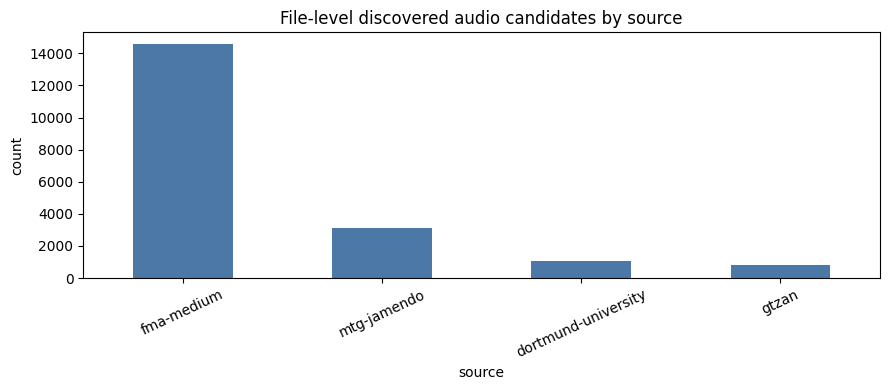

### Counts by Genre

,genre_top,count,proportion_pct,imbalance_ratio_vs_max
0,Rock,6203,31.65,1.000
1,Electronic,5572,28.43,1.113
2,Hip-Hop,1835,9.36,3.380
3,Jazz,1091,5.57,5.686
4,Classical,995,5.08,6.234
5,Pop,949,4.84,6.536
6,Blues,935,4.77,6.634
7,Country,884,4.51,7.017
8,Folk,759,3.87,8.173
9,Metal,376,1.92,16.497


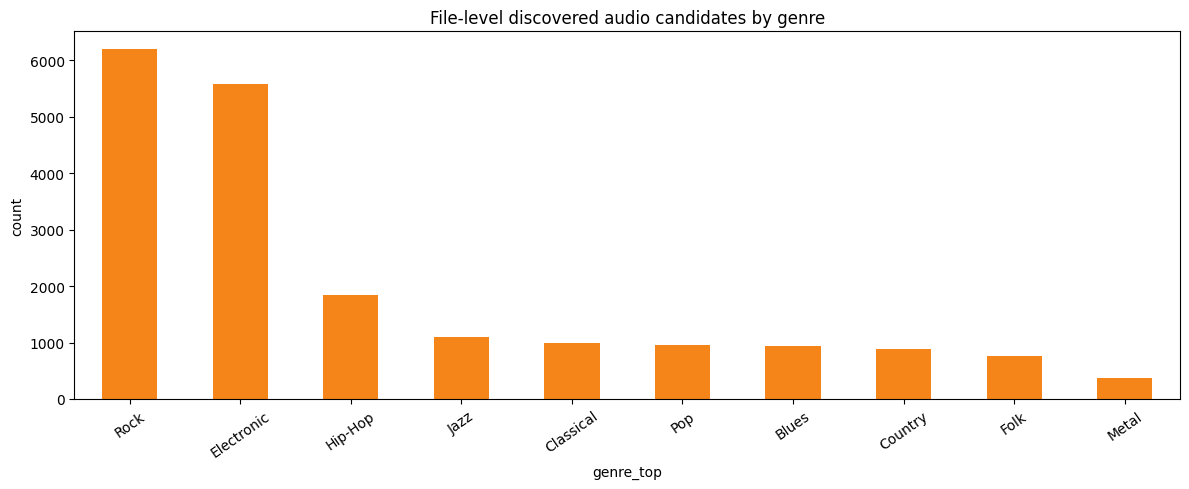

### Reason Code Breakdown

,reason_code,count
0,OK,19585
1,AUDIO_READ_FAILED,12
2,TOO_SHORT,2


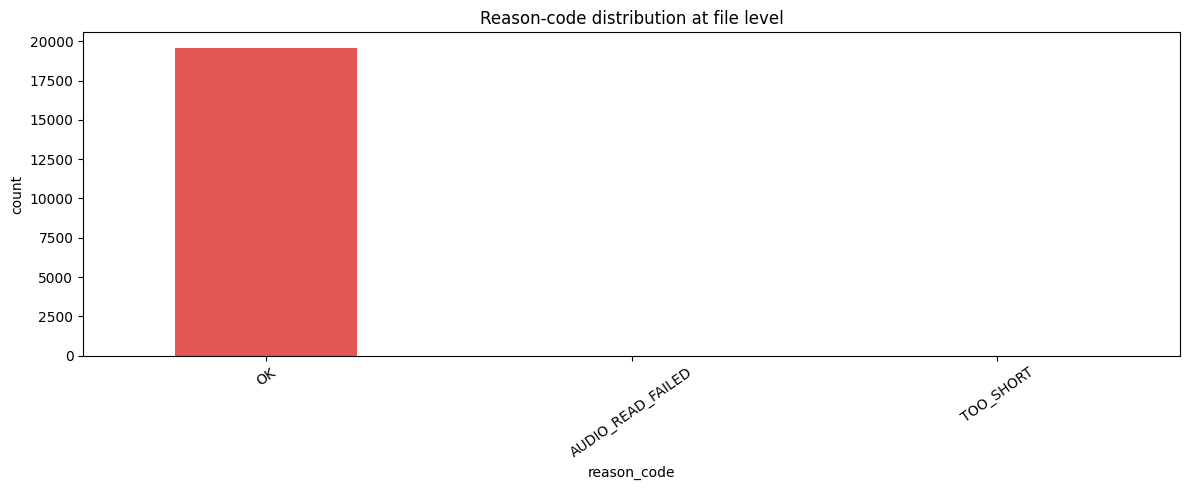

### Sampling Eligibility

,sampling_eligible,count
0,True,19585
1,False,14


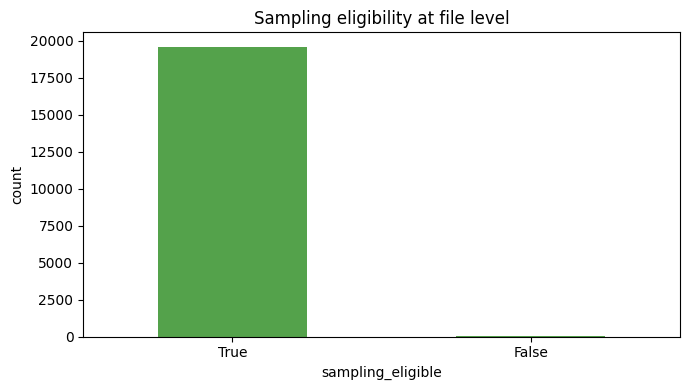

### Duration Summary

,count,mean,std,min,25%,50%,75%,max,missing_pct
actual_duration_s,19587.0,25.852126,7.916695,6.321633,29.988571,29.988571,30.014694,30.648889,0.06
duration_s,19587.0,25.903763,7.818148,7.000000,30.000000,30.000000,30.000000,31.000000,0.06


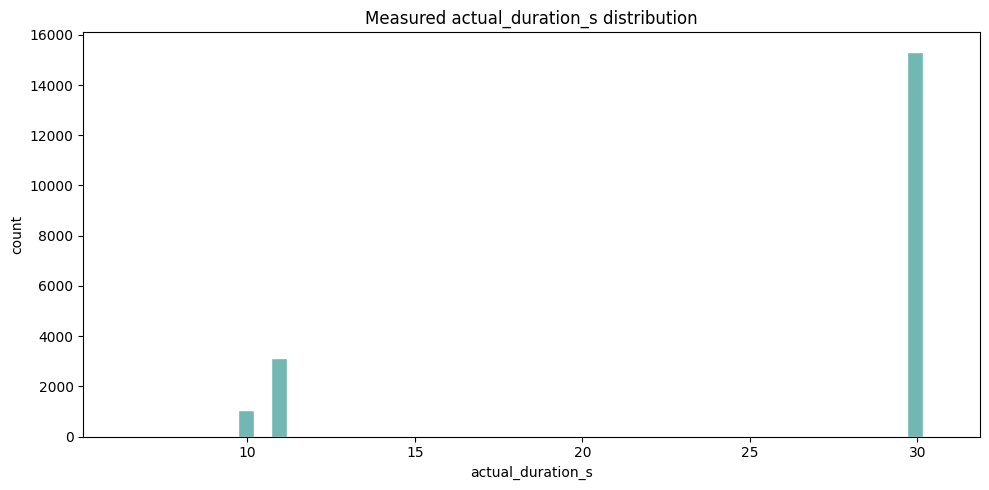

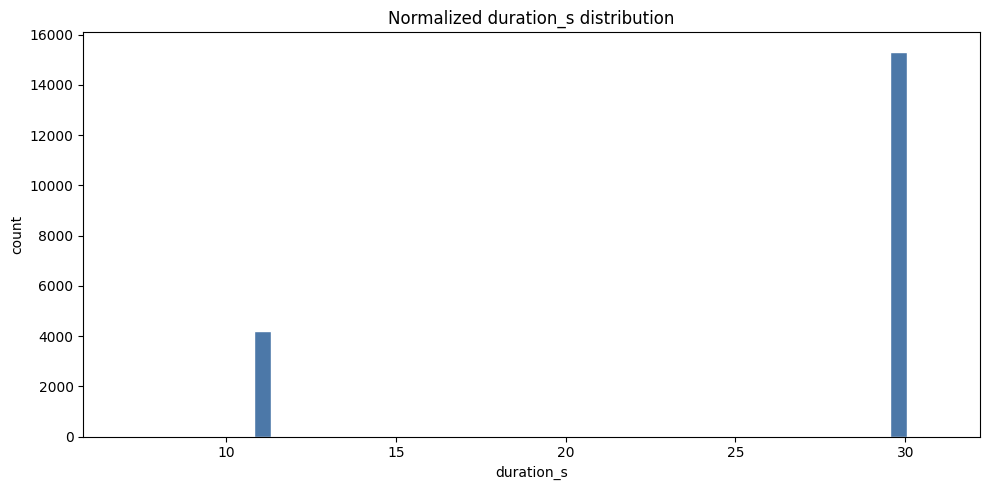

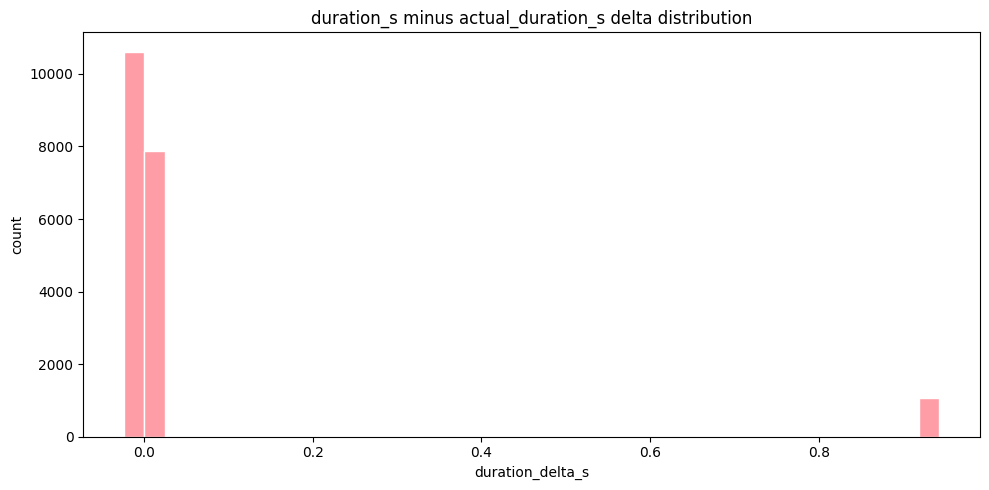

In [6]:
file_level_summary = pd.DataFrame([
    {'metric': 'total_discovered_audio_candidates', 'value': len(all_datasets_df)},
    {'metric': 'audio_exists_true', 'value': int(all_datasets_df['audio_exists'].fillna(False).sum())},
    {'metric': 'reason_code_OK', 'value': int((all_datasets_df['reason_code'] == 'OK').sum())},
    {'metric': 'sampling_eligible_true', 'value': int(all_datasets_df['sampling_eligible'].fillna(False).sum())},
    {'metric': 'unique_sources', 'value': all_datasets_df['source'].nunique(dropna=True)},
    {'metric': 'unique_genres', 'value': all_datasets_df['genre_top'].nunique(dropna=True)},
])
display(file_level_summary)

source_counts = all_datasets_df['source'].value_counts()
genre_counts = all_datasets_df['genre_top'].value_counts()
reason_counts = all_datasets_df['reason_code'].value_counts()
eligibility_counts = all_datasets_df['sampling_eligible'].astype(str).value_counts()

display(Markdown('### Counts by Source'))
display(source_counts.rename_axis('source').reset_index(name='count'))
plot_bar(source_counts, title='File-level discovered audio candidates by source', xlabel='source', rotation=25, figsize=(9, 4))

display(Markdown('### Counts by Genre'))
display(imbalance_table(all_datasets_df['genre_top'], name='genre_top'))
plot_bar(genre_counts, title='File-level discovered audio candidates by genre', xlabel='genre_top', rotation=35, figsize=(12, 5), color='#F58518')

display(Markdown('### Reason Code Breakdown'))
display(reason_counts.rename_axis('reason_code').reset_index(name='count'))
plot_bar(reason_counts, title='Reason-code distribution at file level', xlabel='reason_code', rotation=35, figsize=(12, 5), color='#E45756')

display(Markdown('### Sampling Eligibility'))
display(eligibility_counts.rename_axis('sampling_eligible').reset_index(name='count'))
plot_bar(eligibility_counts, title='Sampling eligibility at file level', xlabel='sampling_eligible', rotation=0, figsize=(7, 4), color='#54A24B')

duration_summary = all_datasets_df[['actual_duration_s', 'duration_s']].describe().T
duration_summary['missing_pct'] = all_datasets_df[['actual_duration_s', 'duration_s']].isna().mean().mul(100).round(2)
display(Markdown('### Duration Summary'))
display(duration_summary)

duration_analysis_df = all_datasets_df.copy()
duration_analysis_df['duration_delta_s'] = duration_analysis_df['duration_s'] - duration_analysis_df['actual_duration_s']
plot_hist(duration_analysis_df['actual_duration_s'], title='Measured actual_duration_s distribution', bins=50)
plot_hist(duration_analysis_df['duration_s'], title='Normalized duration_s distribution', bins=50, color='#4C78A8')
plot_hist(duration_analysis_df['duration_delta_s'], title='duration_s minus actual_duration_s delta distribution', bins=40, color='#FF9DA6')

## Segment Expansion and Final Split Audits

This section is the center of the notebook: it connects Stage 1 segment generation to the Stage 2 manifest that training and downstream feature extraction actually consume.

The goal here is to verify both quantity and structure before moving on to smaller specialized checks.

The main questions are:

- how many segments each source audio emitted
- how many segments survived into the final manifest
- whether final split assignment preserved source-audio grouping
- whether additional-source contribution is visible and close to the configured target

,metric,value
0,all_sample_rows,50312.00
1,final_sample_rows,12293.00
2,unique_stage1_artifacts,19585.00
3,unique_final_artifacts,6405.00
4,mean_emitted_segments_per_audio,2.57
5,mean_selected_segments_per_audio,1.92


### Emitted Segment Rows by Source

,source,count
0,fma-medium,43694
1,mtg-jamendo,3144
2,gtzan,2397
3,dortmund-university,1077


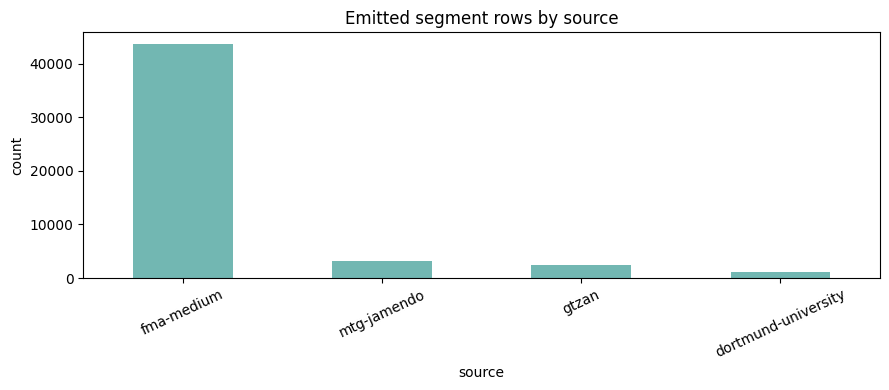

### Emitted Segment Rows by Genre

,genre_top,count,proportion_pct,imbalance_ratio_vs_max
0,Rock,18596,36.96,1.000
1,Electronic,16194,32.19,1.148
2,Hip-Hop,4419,8.78,4.208
3,Classical,2433,4.84,7.643
4,Jazz,2056,4.09,9.045
5,Folk,1794,3.57,10.366
6,Pop,1521,3.02,12.226
7,Country,1440,2.86,12.914
8,Blues,1283,2.55,14.494
9,Metal,576,1.14,32.285


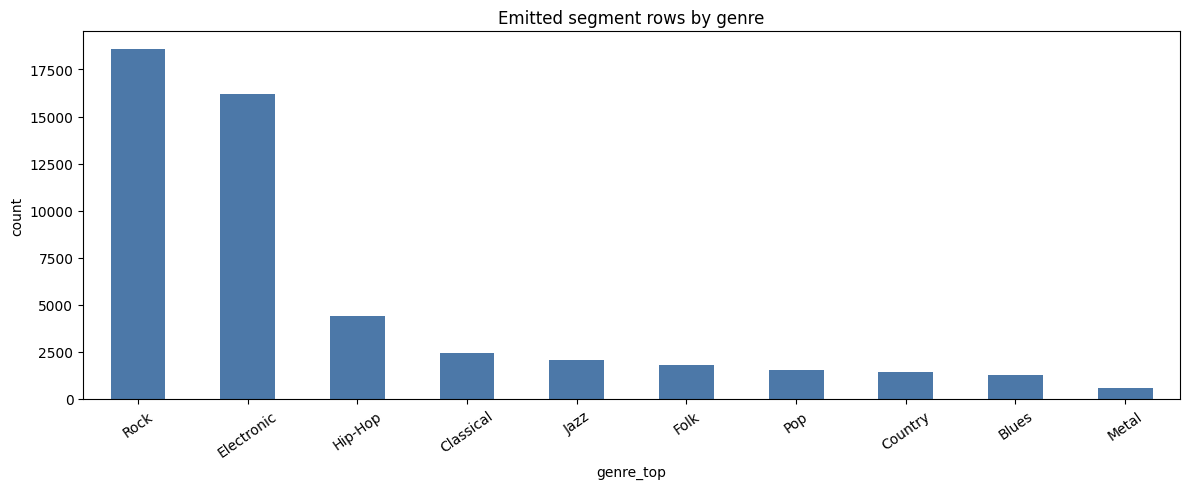

### Final Split Counts

,final_split,count
0,training,9818
1,validation,1238
2,test,1237


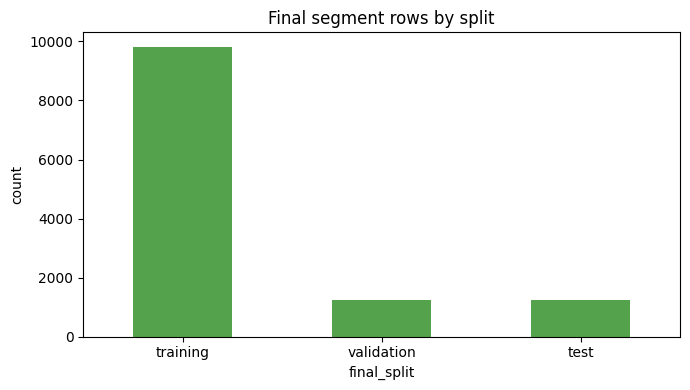

### Final Segment Rows by Genre

,genre_top,count,proportion_pct,imbalance_ratio_vs_max
0,Classical,1306,10.62,1.000
1,Folk,1305,10.62,1.001
2,Hip-Hop,1305,10.62,1.001
3,Jazz,1305,10.62,1.001
4,Rock,1305,10.62,1.001
5,Country,1303,10.60,1.002
6,Pop,1303,10.60,1.002
7,Electronic,1302,10.59,1.003
8,Blues,1283,10.44,1.018
9,Metal,576,4.69,2.267


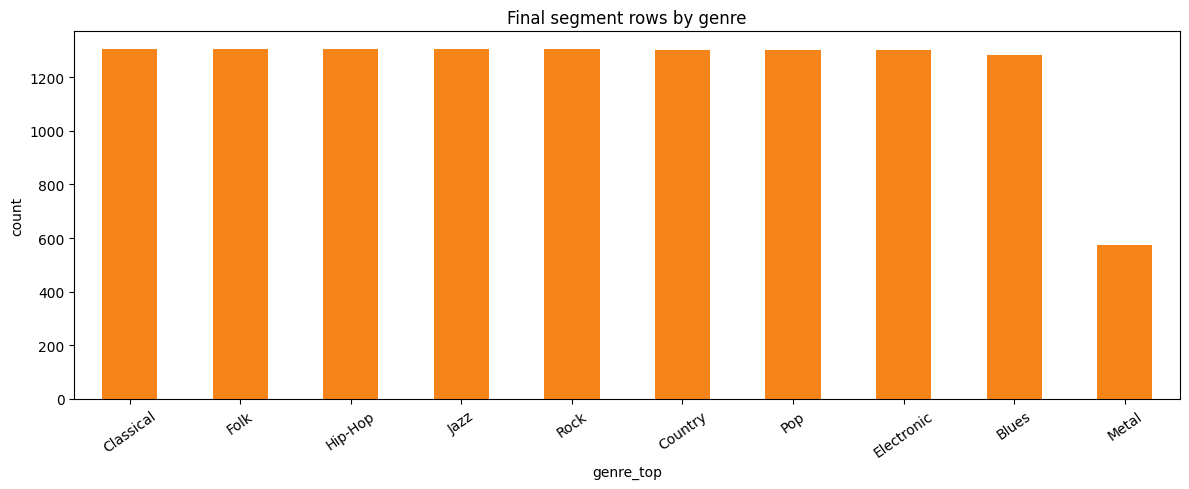

### Final Counts by Genre and Split

final_split,test,training,validation
genre_top,,,
Blues,128,1028,127
Classical,132,1042,132
Country,130,1042,131
Electronic,131,1040,131
Folk,132,1041,132
Hip-Hop,132,1041,132
Jazz,132,1041,132
Metal,58,460,58
Pop,130,1042,131


final_split,test,training,validation
genre_top,,,
Blues,9.98,80.12,9.90
Classical,10.11,79.79,10.11
Country,9.98,79.97,10.05
Electronic,10.06,79.88,10.06
Folk,10.11,79.77,10.11
Hip-Hop,10.11,79.77,10.11
Jazz,10.11,79.77,10.11
Metal,10.07,79.86,10.07
Pop,9.98,79.97,10.05


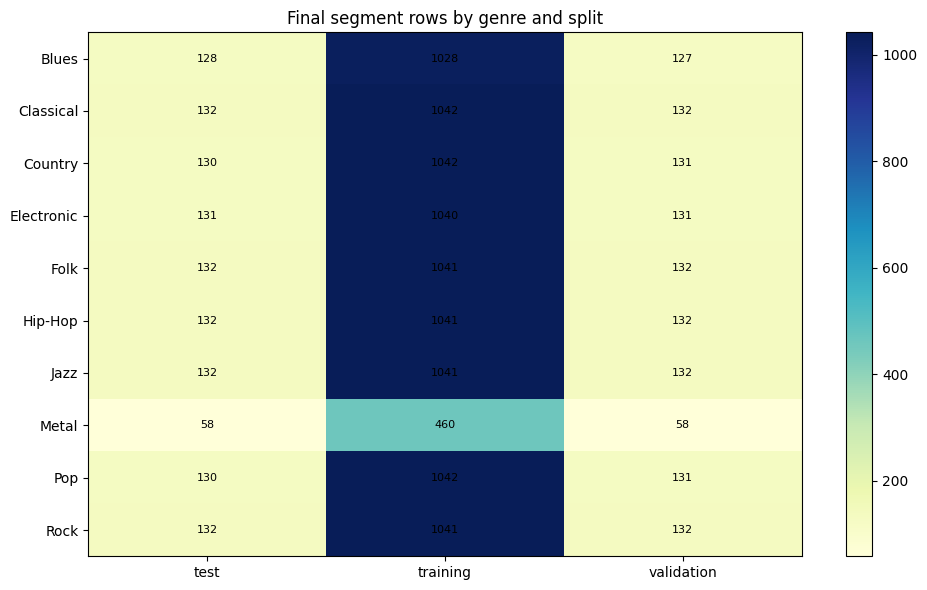

### Leakage-Safety Check

,metric,value
0,artifacts_in_multiple_final_splits,0


Leakage check passed: no source-audio artifact appears in more than one final split.


### Additional-Source Contribution

,metric,value
0,target_additional_contribution_pct,39.00
1,actual_additional_contribution_pct,44.51
2,actual_fma_contribution_pct,55.49


source_family,fma,additional_datasets
genre_top,,
Blues,222,1061
Classical,798,508
Country,534,769
Electronic,1044,258
Folk,1065,240
Hip-Hop,798,507
Jazz,798,507
Metal,0,576
Pop,558,745


source_family,fma,additional_datasets,target_additional_pct,gap_vs_target_pct
genre_top,,,,
Blues,17.30,82.70,39.0,43.70
Classical,61.10,38.90,39.0,-0.10
Country,40.98,59.02,39.0,20.02
Electronic,80.18,19.82,39.0,-19.18
Folk,81.61,18.39,39.0,-20.61
Hip-Hop,61.15,38.85,39.0,-0.15
Jazz,61.15,38.85,39.0,-0.15
Metal,0.00,100.00,39.0,61.00
Pop,42.82,57.18,39.0,18.18


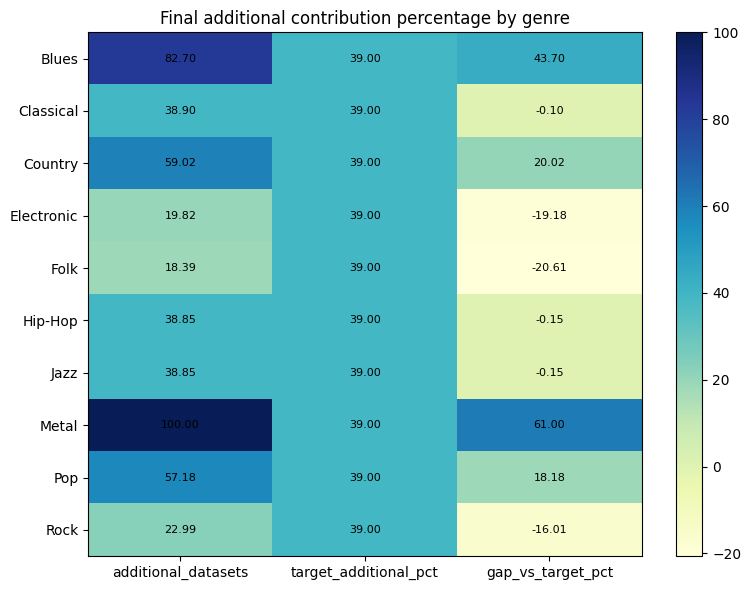

In [7]:
all_samples_audio_level = all_samples_df.copy()
all_samples_audio_level['artifact_id'] = all_samples_audio_level['sample_id'].map(artifact_id_from_sample_id)
all_samples_audio_summary = all_samples_audio_level.groupby('artifact_id').agg(
    source=('source', 'first'),
    genre_top=('genre_top', 'first'),
    duration_s=('duration_s', 'first'),
    actual_duration_s=('actual_duration_s', 'first'),
    total_segments_from_audio=('total_segments_from_audio', 'first'),
    emitted_segments=('sample_id', 'size'),
).reset_index()

final_samples_audio_level = final_samples_df.copy()
final_samples_audio_level['artifact_id'] = final_samples_audio_level['sample_id'].map(artifact_id_from_sample_id)
final_samples_audio_summary = final_samples_audio_level.groupby('artifact_id').agg(
    source=('source', 'first'),
    genre_top=('genre_top', 'first'),
    final_split=('final_split', 'first'),
    selected_segments=('sample_id', 'size'),
).reset_index()

segment_transition_df = all_samples_audio_summary.merge(
    final_samples_audio_summary[['artifact_id', 'final_split', 'selected_segments']],
    on='artifact_id',
    how='left',
)
segment_transition_df['selected_segments'] = segment_transition_df['selected_segments'].fillna(0).astype(int)
segment_transition_df['retained_ratio_pct'] = (segment_transition_df['selected_segments'] / segment_transition_df['emitted_segments']).mul(100).round(2)

transition_summary = pd.DataFrame([
    {'metric': 'all_sample_rows', 'value': len(all_samples_df)},
    {'metric': 'final_sample_rows', 'value': len(final_samples_df)},
    {'metric': 'unique_stage1_artifacts', 'value': len(all_samples_audio_summary)},
    {'metric': 'unique_final_artifacts', 'value': len(final_samples_audio_summary)},
    {'metric': 'mean_emitted_segments_per_audio', 'value': round(all_samples_audio_summary['emitted_segments'].mean(), 2)},
    {'metric': 'mean_selected_segments_per_audio', 'value': round(final_samples_audio_summary['selected_segments'].mean(), 2)},
])
display(transition_summary)

segments_by_source = all_samples_df['source'].value_counts()
segments_by_genre = all_samples_df['genre_top'].value_counts()
final_split_counts = final_samples_df['final_split'].value_counts()
final_genre_counts = final_samples_df['genre_top'].value_counts()
genre_split_table = pd.crosstab(final_samples_df['genre_top'], final_samples_df['final_split'])
genre_split_pct = genre_split_table.div(genre_split_table.sum(axis=1), axis=0).mul(100).round(2)

display(Markdown('### Emitted Segment Rows by Source'))
display(segments_by_source.rename_axis('source').reset_index(name='count'))
plot_bar(segments_by_source, title='Emitted segment rows by source', xlabel='source', rotation=25, figsize=(9, 4), color='#72B7B2')

display(Markdown('### Emitted Segment Rows by Genre'))
display(imbalance_table(all_samples_df['genre_top'], name='genre_top'))
plot_bar(segments_by_genre, title='Emitted segment rows by genre', xlabel='genre_top', rotation=35, figsize=(12, 5), color='#4C78A8')

display(Markdown('### Final Split Counts'))
display(final_split_counts.rename_axis('final_split').reset_index(name='count'))
plot_bar(final_split_counts, title='Final segment rows by split', xlabel='final_split', rotation=0, figsize=(7, 4), color='#54A24B')

display(Markdown('### Final Segment Rows by Genre'))
display(imbalance_table(final_samples_df['genre_top'], name='genre_top'))
plot_bar(final_genre_counts, title='Final segment rows by genre', xlabel='genre_top', rotation=35, figsize=(12, 5), color='#F58518')

display(Markdown('### Final Counts by Genre and Split'))
display(genre_split_table)
display(genre_split_pct)
plot_heatmap(genre_split_table.astype(float), title='Final segment rows by genre and split', figsize=(10, 6), fmt='.0f')

artifact_split_counts = final_samples_audio_level.groupby('artifact_id')['final_split'].nunique()
leakage_artifacts = artifact_split_counts[artifact_split_counts > 1]
leakage_count = int(leakage_artifacts.shape[0])
display(Markdown('### Leakage-Safety Check'))
display(pd.DataFrame([{'metric': 'artifacts_in_multiple_final_splits', 'value': leakage_count}]))
if leakage_count == 0:
    print('Leakage check passed: no source-audio artifact appears in more than one final split.')
else:
    display(leakage_artifacts.rename('num_splits').reset_index())

final_samples_source_view = final_samples_df.copy()
final_samples_source_view['source_family'] = np.where(
    final_samples_source_view['source'].astype(str).str.casefold().str.startswith('fma'),
    'fma',
    'additional_datasets',
)
additional_ratio_target_pct = round(float(sampling_settings.get('additional_samples_contribution_ratio_expected_each_genre', 0.0)) * 100, 2)
overall_source_counts = final_samples_source_view['source_family'].value_counts().reindex(['fma', 'additional_datasets'], fill_value=0)
overall_additional_share_pct = round(overall_source_counts.get('additional_datasets', 0) / max(len(final_samples_source_view), 1) * 100, 2)
genre_source_table = pd.crosstab(final_samples_source_view['genre_top'], final_samples_source_view['source_family']).reindex(columns=['fma', 'additional_datasets'], fill_value=0)
genre_source_pct = genre_source_table.div(genre_source_table.sum(axis=1), axis=0).mul(100).round(2)
genre_source_pct['target_additional_pct'] = additional_ratio_target_pct
genre_source_pct['gap_vs_target_pct'] = (genre_source_pct['additional_datasets'] - genre_source_pct['target_additional_pct']).round(2)

display(Markdown('### Additional-Source Contribution'))
display(pd.DataFrame([
    {'metric': 'target_additional_contribution_pct', 'value': additional_ratio_target_pct},
    {'metric': 'actual_additional_contribution_pct', 'value': overall_additional_share_pct},
    {'metric': 'actual_fma_contribution_pct', 'value': round(100 - overall_additional_share_pct, 2)},
]))
display(genre_source_table)
display(genre_source_pct)
plot_heatmap(genre_source_pct[['additional_datasets', 'target_additional_pct', 'gap_vs_target_pct']].astype(float), title='Final additional contribution percentage by genre', figsize=(8, 6), fmt='.2f')

## Supplementation-Aware Small-Split Audit

After auditing the generic final manifest, this section narrows to the small-dataset workflow where official FMA membership, live processed split parquets, and staged supplementation payloads can diverge.

That distinction matters because `extra_samples_for_small_dataset.json` may already describe candidate supplementation while the current `train_small`, `val_small`, and `test_small` parquet files may still reflect the unsupplemented state.

This section answers four practical questions when the small workflow is active:

1. What does the official exact FMA-small split look like?
2. What do the current processed `train_small`, `val_small`, and `test_small` parquet files contain right now?
3. Have the live processed small splits already diverged from official exact-small through non-FMA or supplementation-driven rows?
4. What payload is currently staged in `extra_samples_for_small_dataset.json` by genre and source?

If those artifacts are missing, this section skips cleanly and the broader manifest audit still remains valid.

In [8]:
supplementation_audit_ready = False
official_small_df = None
processed_small_df = None
official_small_counts = pd.DataFrame()
processed_small_counts = pd.DataFrame()
processed_small_source_summary = pd.DataFrame()
payload_source_summary = pd.DataFrame()
payload_genre_source_summary = pd.DataFrame()
payload_allocation_summary = pd.DataFrame()
supplementation_metrics_table = pd.DataFrame()
current_has_non_fma_rows = False
selected_payload_rows = 0
official_current_row_delta = 0
new_genres_vs_official_small = []


def stable_row_key(row: dict[str, object]) -> str:
    track_id = row.get('track_id')
    filepath = row.get('filepath') or row.get('relative_path') or row.get('filename') or ''
    return '|'.join([
        str(row.get('source') or ''),
        str(row.get('genre') or row.get('genre_top') or ''),
        '' if track_id is None else str(track_id),
        str(filepath),
    ])


def genre_seed(base_seed: int, genre: str) -> int:
    digest = hashlib.sha1(genre.encode('utf-8')).digest()
    genre_hash = int.from_bytes(digest[:4], byteorder='big', signed=False)
    return base_seed + genre_hash


def deterministic_shuffle(rows: list[dict[str, object]], seed: int, genre: str) -> list[dict[str, object]]:
    shuffled = list(rows)
    shuffled.sort(key=stable_row_key)
    random.Random(genre_seed(seed, genre)).shuffle(shuffled)
    return shuffled


def compute_split_counts(total: int, train_ratio: float) -> dict[str, int]:
    train_count = int(round(total * train_ratio))
    train_count = max(0, min(total, train_count))

    remainder = total - train_count
    if remainder % 2 == 1:
        train_count += 1
        remainder -= 1

    val_count = remainder // 2
    test_count = remainder // 2
    return {
        'training': train_count,
        'validation': val_count,
        'test': test_count,
    }


def counts_by_genre_and_split(frame: pd.DataFrame) -> pd.DataFrame:
    table = pd.crosstab(frame['genre_top'], frame['split'])
    return table.reindex(columns=SUPPLEMENTED_SPLIT_ORDER, fill_value=0).sort_index()


def proportions_from_counts(counts: pd.DataFrame) -> pd.DataFrame:
    return counts.div(counts.sum(axis=0), axis=1).fillna(0.0)


def tvd(p: np.ndarray, q: np.ndarray) -> float:
    return 0.5 * np.abs(p - q).sum()


def jsd(p: np.ndarray, q: np.ndarray, eps: float = 1e-12) -> float:
    p = np.clip(p, eps, 1.0)
    p = p / p.sum()
    q = np.clip(q, eps, 1.0)
    q = q / q.sum()
    m = 0.5 * (p + q)
    return 0.5 * (np.sum(p * np.log2(p / m)) + np.sum(q * np.log2(q / m)))


def split_distance_metrics(counts: pd.DataFrame) -> dict[str, float]:
    props = proportions_from_counts(counts)
    genres = props.index
    p_train = props['training'].reindex(genres).to_numpy()
    p_val = props['validation'].reindex(genres).to_numpy()
    p_test = props['test'].reindex(genres).to_numpy()
    return {
        'TVD(train,val)': tvd(p_train, p_val),
        'TVD(train,test)': tvd(p_train, p_test),
        'JSD(train,val)': jsd(p_train, p_val),
        'JSD(train,test)': jsd(p_train, p_test),
    }


def add_all_column(counts: pd.DataFrame) -> pd.DataFrame:
    table = counts.reindex(columns=SUPPLEMENTED_SPLIT_ORDER, fill_value=0).astype(int).copy()
    table['all'] = table.sum(axis=1)
    return table.sort_values('all', ascending=False)


small_split_paths_exist = all((PROCESSED_DIR / filename).exists() for filename in SUPPLEMENTED_SPLIT_FILES.values())
extra_samples_exists = EXTRA_SAMPLES_PATH.exists()
tracks_csv_exists = TRACKS_CSV.exists()

if tracks_csv_exists and small_split_paths_exist:
    tracks = pd.read_csv(TRACKS_CSV, header=[0, 1], index_col=0)
    official_mask = (
        (tracks[('set', 'subset')] == SUPPLEMENTED_TARGET_SUBSET)
        & tracks[('track', 'genre_top')].notna()
        & tracks[('set', 'split')].isin(SUPPLEMENTED_SPLIT_ORDER)
    )
    official_small_df = tracks.loc[official_mask, [('set', 'split'), ('track', 'genre_top')]].copy()
    official_small_df.columns = ['split', 'genre_top']
    official_small_df['source'] = 'fma'
    official_small_df['sample_id'] = official_small_df.index.map(lambda track_id: f'fma:{int(track_id)}')
    official_small_df.index.name = 'track_id'

    processed_small_frames = []
    for split_name, filename in SUPPLEMENTED_SPLIT_FILES.items():
        split_path = PROCESSED_DIR / filename
        frame = pd.read_parquet(split_path).copy()
        frame['split'] = split_name
        frame.index.name = 'track_id'
        processed_small_frames.append(frame)
    processed_small_df = pd.concat(processed_small_frames, axis=0)

    official_small_counts = counts_by_genre_and_split(official_small_df)
    processed_small_counts = counts_by_genre_and_split(processed_small_df)

    official_split_sizes = official_small_df['split'].value_counts().reindex(SUPPLEMENTED_SPLIT_ORDER, fill_value=0)
    processed_split_sizes = processed_small_df['split'].value_counts().reindex(SUPPLEMENTED_SPLIT_ORDER, fill_value=0)
    split_size_compare = pd.concat(
        [
            official_split_sizes.rename('official_exact_small'),
            processed_split_sizes.rename('processed_current'),
        ],
        axis=1,
    )
    split_size_compare['delta_vs_official'] = split_size_compare['processed_current'] - split_size_compare['official_exact_small']

    processed_small_source_summary = (
        processed_small_df.groupby(['split', 'source']).size().unstack(fill_value=0).reindex(SUPPLEMENTED_SPLIT_ORDER, fill_value=0)
    )

    current_has_non_fma_rows = 'source' in processed_small_df.columns and processed_small_df['source'].astype(str).ne('fma').any()
    new_genres_vs_official_small = sorted(set(processed_small_counts.index) - set(official_small_counts.index))
    official_current_row_delta = int(processed_small_df.shape[0] - official_small_df.shape[0])

    display(Markdown('### Official Exact-Small vs Current Processed Small Splits'))
    display(split_size_compare)
    display(Markdown('### Current Processed Small Source Mix by Split'))
    display(processed_small_source_summary)
    print(f'Non-FMA rows already present in processed small splits? {current_has_non_fma_rows}')
    print(f'Genres outside official exact-small currently present: {new_genres_vs_official_small}')

    display(Markdown('### Official Exact-Small Genre Counts'))
    display(official_small_counts)
    display(Markdown('### Current Processed Small Genre Counts'))
    display(processed_small_counts)

    fig, axes = plt.subplots(1, 3, figsize=(22, 5))
    pd.DataFrame({
        'official': official_split_sizes,
        'current': processed_split_sizes,
    }).plot(kind='bar', ax=axes[0], width=0.75)
    axes[0].set_title('Split sizes: official vs current small')
    axes[0].set_ylabel('Rows')
    axes[0].tick_params(axis='x', rotation=0)

    top_genres = (
        processed_small_counts.sum(axis=1)
        .add(official_small_counts.sum(axis=1), fill_value=0)
        .sort_values(ascending=False)
        .head(12)
        .index
    )
    training_compare = pd.DataFrame({
        'official_training': official_small_counts['training'].reindex(top_genres, fill_value=0),
        'current_training': processed_small_counts['training'].reindex(top_genres, fill_value=0),
    })
    training_compare.plot(kind='bar', ax=axes[1], width=0.8)
    axes[1].set_title('Training split genre counts (top 12)')
    axes[1].set_ylabel('Rows')
    axes[1].tick_params(axis='x', rotation=55)

    if not processed_small_source_summary.empty:
        processed_small_source_summary.plot(kind='bar', stacked=True, ax=axes[2], width=0.75)
        axes[2].set_title('Current processed small source mix by split')
        axes[2].set_ylabel('Rows')
        axes[2].tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.show()

    supplementation_metrics_table = pd.DataFrame({
        'official_exact_small': split_distance_metrics(official_small_counts),
        'processed_current': split_distance_metrics(processed_small_counts),
    }).T.round(4)
    display(Markdown('### Split-Distance Metrics'))
    display(supplementation_metrics_table)

if extra_samples_exists and settings_payload is not None:
    extra_samples_payload = json.loads(EXTRA_SAMPLES_PATH.read_text())
    supplementation_settings = settings_payload.get('small_dataset_supplementation', {})
    target_genres = supplementation_settings.get('target_genres', [])
    n_extra_expected = int(supplementation_settings.get('n_extra_expected', 0) or 0)
    train_ratio = float(supplementation_settings.get('train_n_val_test_split_ratio', 0.8) or 0.8)
    selected_tracks = extra_samples_payload.get('selected_tracks', {})

    allocation_records = []
    allocation_summary_records = []
    for genre in target_genres:
        genre_rows = list(selected_tracks.get(genre, []))[:n_extra_expected]
        shuffled_rows = deterministic_shuffle(genre_rows, SUPPLEMENTATION_BASE_RANDOM_SEED, genre)
        split_counts = compute_split_counts(len(shuffled_rows), train_ratio)

        for row in shuffled_rows:
            allocation_records.append({
                'genre_top': genre,
                'source': row.get('source', 'unknown'),
                'track_id': row.get('track_id'),
                'filepath': row.get('filepath'),
            })

        allocation_summary_records.append({
            'genre_top': genre,
            'selected_rows_used': len(shuffled_rows),
            'cap_per_genre': n_extra_expected,
            'train_would_get': split_counts['training'],
            'validation_would_get': split_counts['validation'],
            'test_would_get': split_counts['test'],
        })

    allocation_df = pd.DataFrame(allocation_records)
    payload_allocation_summary = pd.DataFrame(allocation_summary_records).set_index('genre_top').sort_values('selected_rows_used', ascending=False)
    selected_payload_rows = int(len(allocation_df))

    display(Markdown('### Supplementation Payload Allocation Summary'))
    display(payload_allocation_summary)

    if allocation_df.empty:
        print('No selected supplementation rows were found in extra_samples_for_small_dataset.json.')
    else:
        payload_source_summary = (
            allocation_df.groupby('source').size().rename('selected_rows').sort_values(ascending=False).to_frame()
        )
        payload_genre_source_summary = (
            allocation_df.groupby(['genre_top', 'source']).size().unstack(fill_value=0).sort_index()
        )
        display(Markdown('### Supplementation Payload Source Mix'))
        display(payload_source_summary)
        display(Markdown('### Supplementation Payload Rows by Genre and Source'))
        display(payload_genre_source_summary)

        fig, axes = plt.subplots(1, 2, figsize=(18, 5))
        payload_allocation_summary['selected_rows_used'].sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='#4C78A8')
        axes[0].set_title('Selected supplementation payload rows per target genre')
        axes[0].set_ylabel('Rows')
        axes[0].tick_params(axis='x', rotation=55)

        payload_source_summary['selected_rows'].plot(kind='bar', ax=axes[1], color='#F58518')
        axes[1].set_title('Supplementation payload source mix')
        axes[1].set_ylabel('Rows')
        axes[1].tick_params(axis='x', rotation=35)
        plt.tight_layout()
        plt.show()

supplementation_audit_ready = tracks_csv_exists and small_split_paths_exist
if not supplementation_audit_ready:
    print('Supplementation-aware small-split audit is skipped because official small metadata or processed small split parquet files are missing.')
if not extra_samples_exists:
    print('No extra_samples_for_small_dataset.json found; payload provenance portion of the supplementation-aware audit is unavailable.')

Supplementation-aware small-split audit is skipped because official small metadata or processed small split parquet files are missing.
No extra_samples_for_small_dataset.json found; payload provenance portion of the supplementation-aware audit is unavailable.


## Downstream Log-Mel Cache Audit

This final section checks the handoff from the selected manifest into feature materialization by `2_build_log_mel_dataset.py`.

The notebook still treats log-mel indexes as optional downstream artifacts: the manifest layer is the required audit boundary, and the cache layer is a readiness check on top of it.

,artifact,exists
0,logmel_config.json,True
1,logmel_manifest_all.parquet,True
2,logmel_manifest_train.parquet,True
3,logmel_manifest_val.parquet,True
4,logmel_manifest_test.parquet,True


### logmel_config.json

,key,value
0,manifest,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed/manifest_final_samples.parquet
1,out_root,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/cache/logmel_dataset_10s
2,rows_requested,12293
3,sample_rate,22050
4,sample_length_sec,10.0
5,n_mels,192
6,n_fft,512
7,hop_length,256
8,n_frames,861
9,audio_backend,ffmpeg


### logmel_manifest_all

shape = (12293, 25)


...

shape = (1237, 25)


,sample_id,source,genre_top,filepath,track_id,sample_length_sec,segment_index,segment_start_sec,segment_end_sec,total_segments_from_audio,duration_s,actual_duration_s,reason_code,final_split,split_dir,logmel_path,logmel_relpath,logmel_status,logmel_reason,logmel_usable,logmel_shape,sample_rate,n_mels,n_fft,hop_length
0,dortmund-university:Blues:additional_datasets/data/dortmund-university/blues/Andy_Kimbel-Red_Hot_Blues.mp3:seg0000,dortmund-university,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university/blues/Andy_Kimbel-Red_Hot_Blues.mp3,<NA>,10.0,0,0.0,10.0,1,11.0,10.057125,OK,test,test,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/cache/logmel_dataset_10s/test/Blues/3b24790650559050751b.npy,test/Blues/3b24790650559050751b.npy,ok,,True,192x861,22050,192,512,256
1,dortmund-university:Blues:additional_datasets/data/dortmund-university/blues/Dale_Jackson_Band-Not_One_Soul_Told_Me.mp3:seg0000,dortmund-university,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university/blues/Dale_Jackson_Band-Not_One_Soul...,<NA>,10.0,0,0.0,10.0,1,11.0,10.057125,OK,test,test,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/cache/logmel_dataset_10s/test/Blues/c378b778bcbee5a6eb24.npy,test/Blues/c378b778bcbee5a6eb24.npy,ok,,True,192x861,22050,192,512,256
2,dortmund-university:Blues:additional_datasets/data/dortmund-university/blues/Eastsouthern-Louisiana.mp3:seg0000,dortmund-university,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university/blues/Eastsouthern-Louisiana.mp3,<NA>,10.0,0,0.0,10.0,1,11.0,10.057125,OK,test,test,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/cache/logmel_dataset_10s/test/Blues/b32d3ce243c7924121e8.npy,test/Blues/b32d3ce243c7924121e8.npy,ok,,True,192x861,22050,192,512,256
3,dortmund-university:Blues:additional_datasets/data/dortmund-university/blues/Funky_Blues_Messiahs-Uptown_Groove.mp3:seg0000,dortmund-university,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university/blues/Funky_Blues_Messiahs-Uptown_Gr...,<NA>,10.0,0,0.0,10.0,1,11.0,10.057125,OK,test,test,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/cache/logmel_dataset_10s/test/Blues/85982ded4a2d6db265af.npy,test/Blues/85982ded4a2d6db265af.npy,ok,,True,192x861,22050,192,512,256
4,dortmund-university:Blues:additional_datasets/data/dortmund-university/blues/Good_bye_Blue_Monday-I_ll_Be_By_Your_Side.mp3:seg0000,dortmund-university,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/dortmund-university/blues/Good_bye_Blue_Monday-I_ll_Be_B...,<NA>,10.0,0,0.0,10.0,1,11.0,10.057125,OK,test,test,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/cache/logmel_dataset_10s/test/Blues/feea6f8f0b246e2cb0ac.npy,test/Blues/feea6f8f0b246e2cb0ac.npy,ok,,True,192x861,22050,192,512,256


,column,dtype,null_count,null_pct
0,sample_id,str,0,0.00
1,source,str,0,0.00
2,genre_top,str,0,0.00
3,filepath,str,0,0.00
4,track_id,Int64,550,44.46
5,sample_length_sec,float64,0,0.00
6,segment_index,int64,0,0.00
7,segment_start_sec,float64,0,0.00
8,segment_end_sec,float64,0,0.00
9,total_segments_from_audio,Int64,0,0.00


,metric,value
0,logmel_manifest_all_rows,12293
1,logmel_manifest_train_rows,9818
2,logmel_manifest_val_rows,1238
3,logmel_manifest_test_rows,1237
4,usable_logmels_all,12293


,split_dir,count
0,test,1237
1,train,9818
2,val,1238


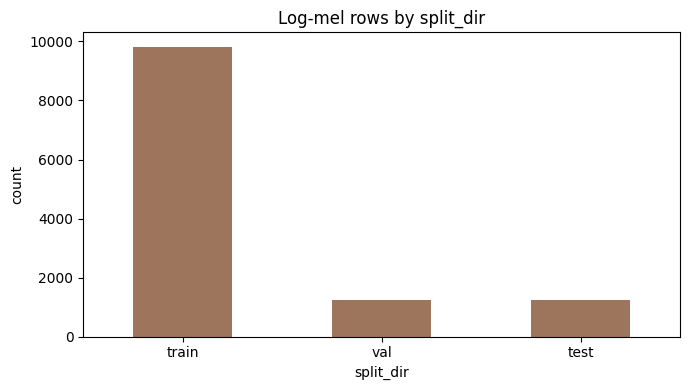

,logmel_status,count
0,ok,12293


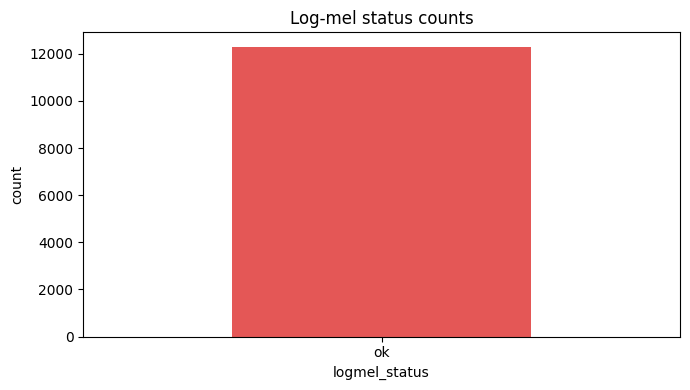

### Final-Manifest to Log-Mel Alignment

,metric,value
0,final_manifest_rows,12293
1,matched_logmel_rows,12293
2,missing_logmel_rows,0
3,matched_and_usable,12293


In [9]:
logmel_presence_rows = [
    {'artifact': 'logmel_config.json', 'exists': LOGMEL_CONFIG_PATH.exists()},
    {'artifact': 'logmel_manifest_all.parquet', 'exists': LOGMEL_ALL_PATH.exists()},
    {'artifact': 'logmel_manifest_train.parquet', 'exists': LOGMEL_TRAIN_PATH.exists()},
    {'artifact': 'logmel_manifest_val.parquet', 'exists': LOGMEL_VAL_PATH.exists()},
    {'artifact': 'logmel_manifest_test.parquet', 'exists': LOGMEL_TEST_PATH.exists()},
]
display(pd.DataFrame(logmel_presence_rows))

if logmel_config is not None:
    display(Markdown('### logmel_config.json'))
    display(pd.DataFrame([{'key': key, 'value': value} for key, value in logmel_config.items()]))

if logmel_all_df is None:
    print('No logmel_manifest_all.parquet found under the configured log-mel dataset root.')
    print('That means the notebook can only audit the manifest layer and the downstream log-mel configuration file.')
else:
    display_frame_overview('logmel_manifest_all', logmel_all_df)
    display_frame_overview('logmel_manifest_train', logmel_train_df)
    display_frame_overview('logmel_manifest_val', logmel_val_df)
    display_frame_overview('logmel_manifest_test', logmel_test_df)

    logmel_summary = pd.DataFrame([
        {'metric': 'logmel_manifest_all_rows', 'value': len(logmel_all_df)},
        {'metric': 'logmel_manifest_train_rows', 'value': len(logmel_train_df)},
        {'metric': 'logmel_manifest_val_rows', 'value': len(logmel_val_df)},
        {'metric': 'logmel_manifest_test_rows', 'value': len(logmel_test_df)},
        {'metric': 'usable_logmels_all', 'value': int(logmel_all_df['logmel_usable'].sum()) if 'logmel_usable' in logmel_all_df.columns else None},
    ])
    display(logmel_summary)

    split_dir_counts = logmel_all_df['split_dir'].value_counts().sort_index()
    display(split_dir_counts.rename_axis('split_dir').reset_index(name='count'))
    plot_bar(split_dir_counts, title='Log-mel rows by split_dir', xlabel='split_dir', rotation=0, figsize=(7, 4), color='#9D755D')

    if 'logmel_status' in logmel_all_df.columns:
        status_counts = logmel_all_df['logmel_status'].value_counts()
        display(status_counts.rename_axis('logmel_status').reset_index(name='count'))
        plot_bar(status_counts, title='Log-mel status counts', xlabel='logmel_status', rotation=0, figsize=(7, 4), color='#E45756')

    final_key_cols = ['sample_id', 'genre_top', 'final_split', 'segment_index', 'segment_start_sec', 'sample_length_sec']
    logmel_key_cols = ['sample_id', 'genre_top', 'split_dir', 'segment_index', 'segment_start_sec', 'sample_length_sec']
    alignment_left = final_samples_df[final_key_cols].copy()
    alignment_left['split_dir'] = alignment_left['final_split'].map({'training': 'train', 'validation': 'val', 'test': 'test'})
    alignment_left = alignment_left.drop(columns=['final_split'])
    alignment_merge = alignment_left.merge(
        logmel_all_df[logmel_key_cols + ['logmel_path', 'logmel_status', 'logmel_usable']].copy(),
        on=logmel_key_cols,
        how='left',
        indicator=True,
    )
    alignment_summary = pd.DataFrame([
        {'metric': 'final_manifest_rows', 'value': len(alignment_merge)},
        {'metric': 'matched_logmel_rows', 'value': int((alignment_merge['_merge'] == 'both').sum())},
        {'metric': 'missing_logmel_rows', 'value': int((alignment_merge['_merge'] != 'both').sum())},
        {'metric': 'matched_and_usable', 'value': int(((alignment_merge['_merge'] == 'both') & (alignment_merge['logmel_usable'] == True)).sum())},
    ])
    display(Markdown('### Final-Manifest to Log-Mel Alignment'))
    display(alignment_summary)
    if int((alignment_merge['_merge'] != 'both').sum()) > 0:
        display(alignment_merge[alignment_merge['_merge'] != 'both'].head(20))

In [10]:
final_split_counts = final_samples_df['final_split'].value_counts()
smallest_final_genre = final_samples_df['genre_top'].value_counts().idxmin() if not final_samples_df.empty else 'N/A'
dominant_file_genre = all_datasets_df['genre_top'].value_counts().idxmax() if not all_datasets_df.empty else 'N/A'
top_reason_code = all_datasets_df['reason_code'].value_counts().idxmax() if not all_datasets_df.empty else 'N/A'
mean_emitted_segments = round(all_samples_audio_summary['emitted_segments'].mean(), 2) if not all_samples_audio_summary.empty else 0
training_share_pct = round(final_split_counts.get('training', 0) / max(len(final_samples_df), 1) * 100, 2)
mean_genre_additional_gap_pct = round(genre_source_pct['gap_vs_target_pct'].abs().mean(), 2) if 'genre_source_pct' in globals() and not genre_source_pct.empty else 0
logmel_ready = logmel_all_df is not None

supplementation_status = 'available' if supplementation_audit_ready else 'not available'
supplementation_non_fma_state = current_has_non_fma_rows if supplementation_audit_ready else 'unknown'
supplementation_payload_rows = selected_payload_rows if 'selected_payload_rows' in globals() else 0
supplementation_official_delta = official_current_row_delta if supplementation_audit_ready else 'unknown'
supplementation_new_genres = new_genres_vs_official_small if supplementation_audit_ready else []

summary_markdown = f'''
## Key Findings and Readiness Summary

This closing summary reflects the full audit path: discovery, manifest construction, final split selection, optional small-split supplementation state, and optional log-mel materialization.

1. The file-level discovered dataset is currently dominated by **{dominant_file_genre}**.
2. The most frequent file-level reason code is **{top_reason_code}**.
3. The segment-expansion stage emits an average of **{mean_emitted_segments}** segments per source audio that produced segments.
4. The final manifest assigns **{training_share_pct}%** of selected segment rows to the training split.
5. The configured additional-source target is **{additional_ratio_target_pct}%**, while the current selected manifest achieves **{overall_additional_share_pct}%** overall.
6. The mean absolute per-genre gap versus the configured additional-source target is **{mean_genre_additional_gap_pct} percentage points**.
7. The least represented final genre is **{smallest_final_genre}**.
8. Leakage validation reports **{leakage_count}** source-audio artifacts assigned to more than one final split.
9. Downstream log-mel index availability under the configured root is **{logmel_ready}**.
10. Supplementation-aware small-split audit availability is **{supplementation_status}**.
11. Current processed small-split delta versus official exact-small is **{supplementation_official_delta}** rows.
12. Non-FMA rows already present in processed small splits: **{supplementation_non_fma_state}**.
13. Selected supplementation payload rows currently visible in `extra_samples_for_small_dataset.json`: **{supplementation_payload_rows}**.
14. Genres outside official exact-small currently present in processed small splits: **{supplementation_new_genres}**.

Operational interpretation:

- the manifest layer is the primary source of truth for this notebook
- the final manifest reflects the segment-level multi-source sampling scheme now under review
- source-audio grouping can be checked directly from `sample_id` suffix stripping
- additional-source contribution can be checked at both overall and per-genre levels
- the small-split supplementation section distinguishes between live processed parquets and staged payload candidates instead of assuming they are already synchronized
- downstream log-mel readiness depends on whether split parquet indexes have actually been materialized in the configured cache root
'''
display(Markdown(summary_markdown))


## Key Findings and Readiness Summary

This closing summary reflects the full audit path: discovery, manifest construction, final split selection, optional small-split supplementation state, and optional log-mel materialization.

1. The file-level discovered dataset is currently dominated by **Rock**.
2. The most frequent file-level reason code is **OK**.
3. The segment-expansion stage emits an average of **2.57** segments per source audio that produced segments.
4. The final manifest assigns **79.87%** of selected segment rows to the training split.
5. The configured additional-source target is **39.0%**, while the current selected manifest achieves **44.51%** overall.
6. The mean absolute per-genre gap versus the configured additional-source target is **19.91 percentage points**.
7. The least represented final genre is **Metal**.
8. Leakage validation reports **0** source-audio artifacts assigned to more than one final split.
9. Downstream log-mel index availability under the configured root is **True**.
10. Supplementation-aware small-split audit availability is **not available**.
11. Current processed small-split delta versus official exact-small is **unknown** rows.
12. Non-FMA rows already present in processed small splits: **unknown**.
13. Selected supplementation payload rows currently visible in `extra_samples_for_small_dataset.json`: **0**.
14. Genres outside official exact-small currently present in processed small splits: **[]**.

Operational interpretation:

- the manifest layer is the primary source of truth for this notebook
- the final manifest reflects the segment-level multi-source sampling scheme now under review
- source-audio grouping can be checked directly from `sample_id` suffix stripping
- additional-source contribution can be checked at both overall and per-genre levels
- the small-split supplementation section distinguishes between live processed parquets and staged payload candidates instead of assuming they are already synchronized
- downstream log-mel readiness depends on whether split parquet indexes have actually been materialized in the configured cache root
